# Brain Street View - Example Notebook
Load and plot Allen Mouse Brain Connectivity data ([Oh et al., Nature, 2014](https://doi.org/10.1038/nature13186))

In [1]:
%matplotlib inline

%load_ext autoreload
%autoreload 2
import bsv
from pathlib import Path

## Parameters

In [2]:
# local paths — update these to match your setup
root = Path.home() / "brainstreetview"
save_location = root / 'AllenQueries'
allen_atlas_path = root / 'allenCCF' # download files from https://figshare.com/articles/dataset/Modified_Allen_CCF_2017_for_cortex-lab_allenCCF/25365829 there
file_name = ''

# experiment parameters
input_regions = ['VISam']
mouse_line = ''
primary_injection = True

# loading parameters
subtract_other_hemisphere = False
normalization_method = 'injectionIntensity'

# plotting parameters
number_of_slices = 10
number_of_pixels = 15
output_region = 'CP'
plane = 'coronal'
smoothing = 2
color_limits = 'global'
region_only = True
color = [[0.543, 0, 0], [0, 0.746, 1], [0.180, 0.543, 0.340], [1, 0.547, 0]]

## 1. Find Allen connectivity experiments

In [3]:
experiment_ids = bsv.find_connectivity_experiments(input_regions, mouse_line, primary_injection)
print(f'\nTotal: {len(experiment_ids)} experiments')

Found 38 experiments in VISam

Total: 38 experiments


## 2. Fetch/load experiment data
The first run downloads images from the Allen API and caches them locally. Subsequent runs load from cache.

In [4]:
experiment_imgs, injection_summary, _, experiment_region_info = bsv.fetch_connectivity_data(
    experiment_ids, save_location, file_name,
    normalization_method, subtract_other_hemisphere,
    allen_atlas_path=allen_atlas_path)

print(f'Projection data shape: {experiment_imgs.shape}')

Loading 38 experiments...

EXPERIMENT SUMMARY
Total experiments loaded: 38

Mouse genotype distribution:
  Tlx3-Cre_PL56: 6 experiments
  Ai75(RCL-nT): 6 experiments
  Cux2-IRES-Cre: 5 experiments
  Wild-type: 3 experiments
  Rbp4-Cre_KL100: 3 experiments
  Ntsr1-Cre_GN220: 3 experiments
  Emx1-IRES-Cre: 2 experiments
  Scnn1a-Tg3-Cre: 2 experiments
  A930038C07Rik-Tg1-Cre: 2 experiments
  Gpr26-Cre_KO250: 1 experiments
  Trib2-F2A-CreERT2: 1 experiments
  Drd3-Cre_KI196: 1 experiments
  Efr3a-Cre_NO108: 1 experiments
  Sst-IRES-Cre: 1 experiments
  Sim1-Cre_KJ18: 1 experiments

Brain region distribution:
  VISam: 38 experiments
Getting raw images...
Metadata exported to: /Users/mb7442/brainstreetview/AllenQueries/connectivity_data_metadata.csv
Data processing complete.
Projection data shape: (132, 80, 114, 1)


## 3. Plot projections to target region (2D)

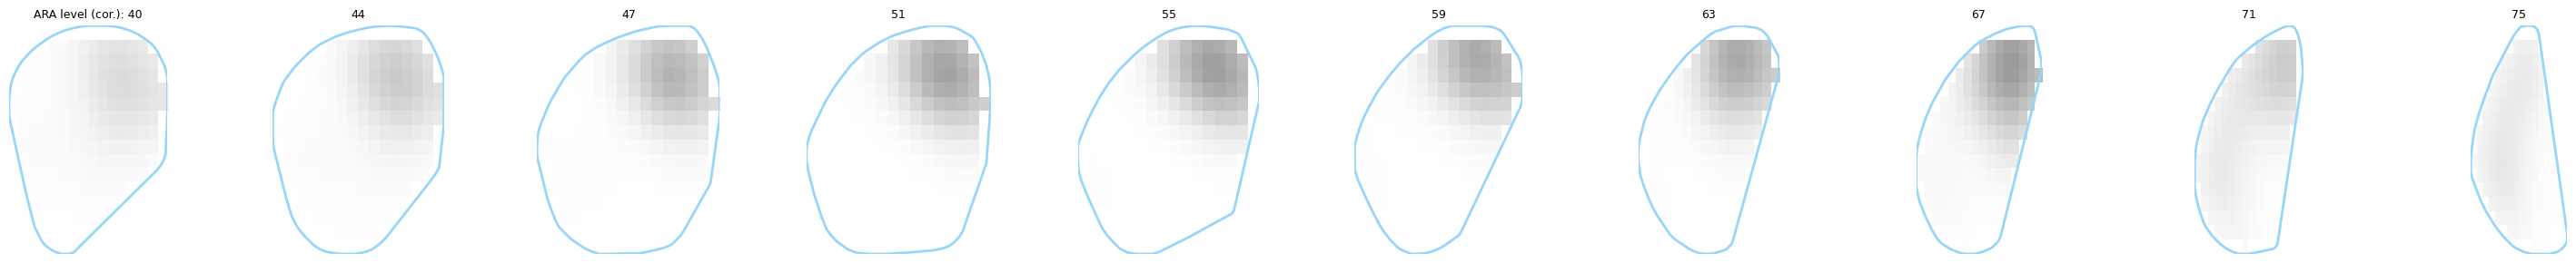

In [7]:
proj_array, proj_coords = bsv.plot_connectivity(
    experiment_imgs, allen_atlas_path, output_region,
    number_of_slices, number_of_pixels, plane,
    region_only, smoothing, color_limits, color, normalization_method)

## 4. Plot injection sites (2D)
Show where injections were made, one row per input region.

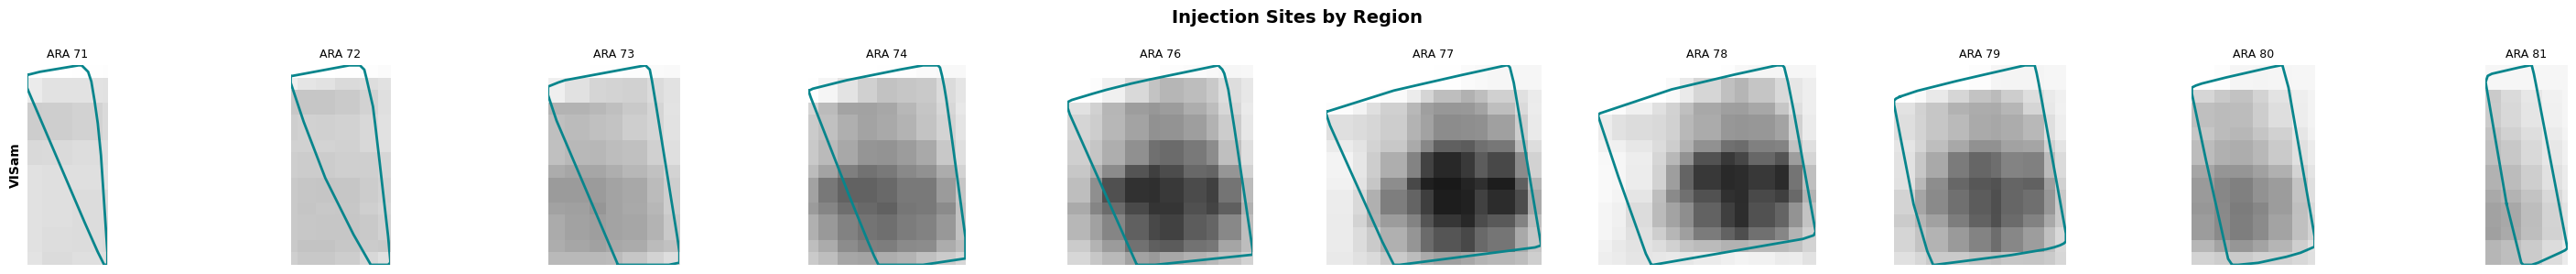

In [8]:
bsv.plot_injections_combined(experiment_imgs, allen_atlas_path, input_regions,
                              number_of_slices, number_of_pixels, plane,
                              region_only, smoothing, color_limits, color,
                              normalization_method)

## 5. Plot with region grouping
Group input regions and plot each group as a separate row.

Found 283 experiments in VISp
Found 68 experiments in VISl
Found 18 experiments in VISal
Found 38 experiments in VISam
Found 15 experiments in VISpl
Found 28 experiments in VISpm
Found 14 experiments in VISli
Found 36 experiments in VISpor
Loading 500 experiments...

EXPERIMENT SUMMARY
Total experiments loaded: 500

Mouse genotype distribution:
  Ai75(RCL-nT): 68 experiments
  Wild-type: 47 experiments
  Cux2-IRES-Cre: 46 experiments
  Tlx3-Cre_PL56: 46 experiments
  A930038C07Rik-Tg1-Cre: 44 experiments
  Emx1-IRES-Cre: 42 experiments
  Rbp4-Cre_KL100: 40 experiments
  Ntsr1-Cre_GN220: 37 experiments
  Scnn1a-Tg3-Cre: 21 experiments
  Syt6-Cre_KI148: 12 experiments
  Rorb-IRES2-Cre: 9 experiments
  Nr5a1-Cre: 9 experiments
  Penk-IRES2-Cre-neo: 8 experiments
  Chrna2-Cre_OE25: 8 experiments
  Efr3a-Cre_NO108: 8 experiments
  Ctgf-T2A-dgCre: 5 experiments
  Drd3-Cre_KI196: 5 experiments
  Slc17a8-IRES2-Cre: 4 experiments
  Sim1-Cre_KJ18: 4 experiments
  Gpr26-Cre_KO250: 4 experiments
 

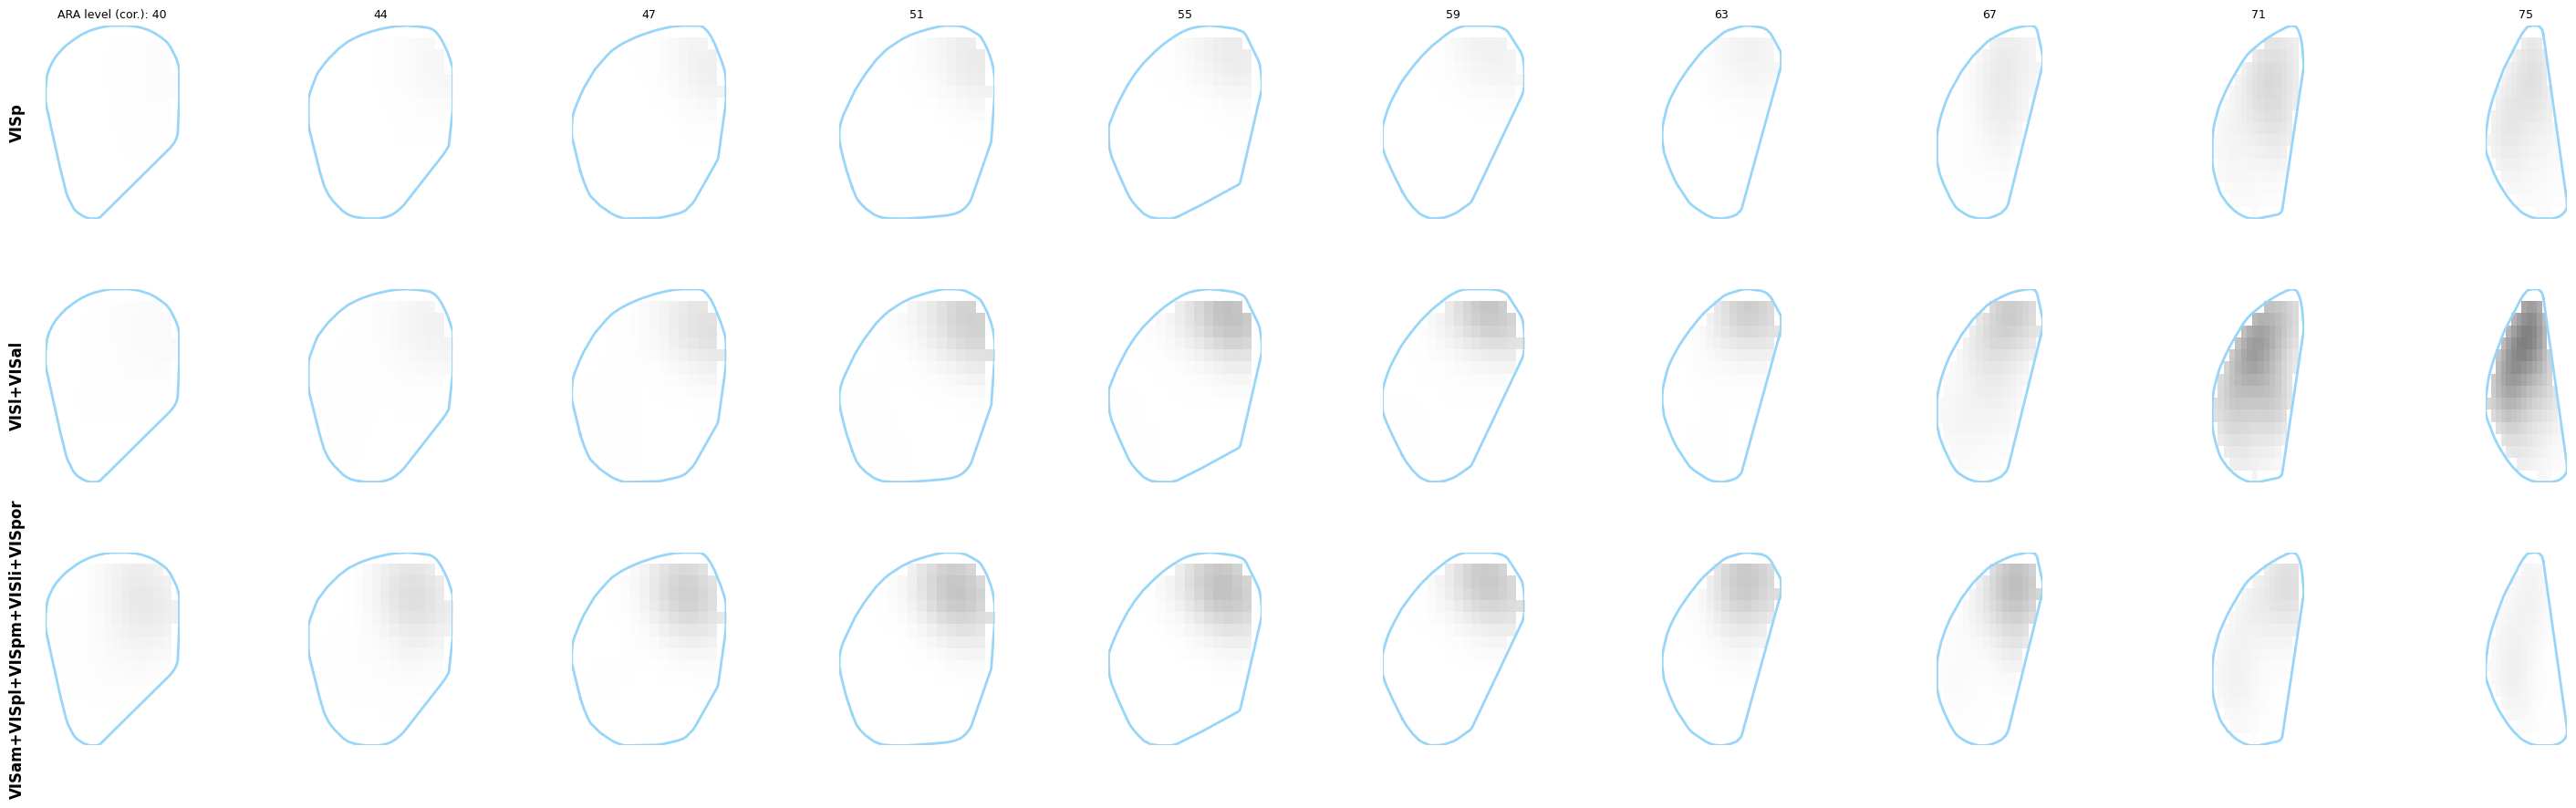

In [9]:
# this example uses all 8 visual regions grouped into 3 rows
grouped_input_regions = ['VISp', 'VISl', 'VISal', 'VISam', 'VISpl', 'VISpm', 'VISli', 'VISpor']
region_groups = [1, 2, 2, 3, 3, 3, 3, 3]

# find experiments for all regions
grouped_exp_ids = bsv.find_connectivity_experiments(grouped_input_regions, mouse_line, primary_injection)

# fetch with grouping
experiment_imgs_grouped, _, _, experiment_region_info_grouped = bsv.fetch_connectivity_data(
    grouped_exp_ids, save_location, file_name,
    normalization_method, subtract_other_hemisphere,
    allen_atlas_path=allen_atlas_path,
    input_regions=grouped_input_regions, region_groups=region_groups)

proj_array_grouped, _ = bsv.plot_connectivity(
    experiment_imgs_grouped, allen_atlas_path, output_region,
    number_of_slices, number_of_pixels, plane,
    region_only, smoothing, color_limits, color, normalization_method,
    input_regions=grouped_input_regions, region_groups=region_groups,
    experiment_region_info=experiment_region_info_grouped)

## 6. Thresholded connectivity

Global data range: 0.000000 to 0.000000
Calculated 90th percentile threshold: 0.1969
Voxels above threshold: 256 (10.0%)
Mean +/- SD: 0.0665 +/- 0.1327


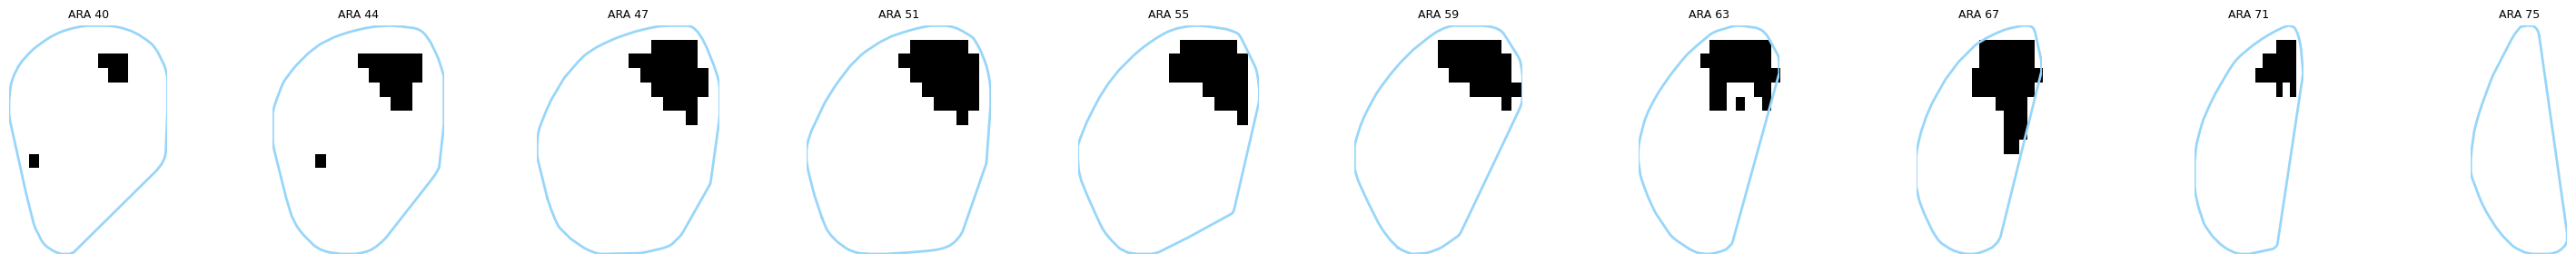

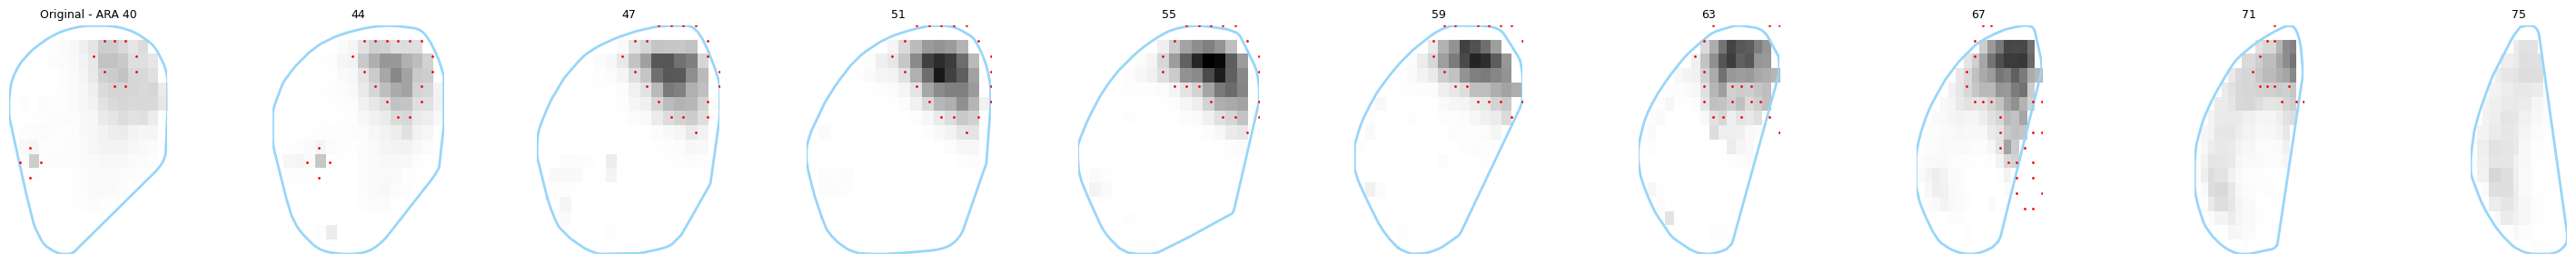

In [9]:
thresh_array, thresh_coords = bsv.threshold_connectivity(
    experiment_imgs, allen_atlas_path, output_region,
    number_of_slices, number_of_pixels, plane,
    region_only, smoothing, color_limits, color,
    threshold=90, threshold_method='percentile',
    normalization_method='none', data_fetch_normalization=normalization_method)

## 7. 3D visualization
Rotating view of the target region with injection sites.

In [ ]:
bsv.plot_connectivity_3d(injection_summary, allen_atlas_path, output_region,
                         color, plot_patch=True, animate=True)